In [1]:
import torch
import numpy as np

# graphing
import matplotlib.pyplot as plt

# data handling
from scipy.io import loadmat
import wfdb

# utilities
import os.path


In [2]:
examples = [
    'A00001', # normal rhythm
    'A00004', # AF rhythm
    'A00077', # other rhythm
    'A01246', # noise
]

data_path = './training2017'
file_name = examples[0]

# read ECG header
hdr = wfdb.rdheader(os.path.join(data_path, file_name)) # .hea suffix appended automatically
samp_count = hdr.sig_len
samp_freq = hdr.fs
gain = hdr.adc_gain
duration = samp_count / samp_freq

# read ECG data
tf = loadmat(os.path.join(data_path, file_name + '.mat'))
y = np.divide(tf['val'].flatten(), gain)
x = np.linspace(0, duration, samp_count)


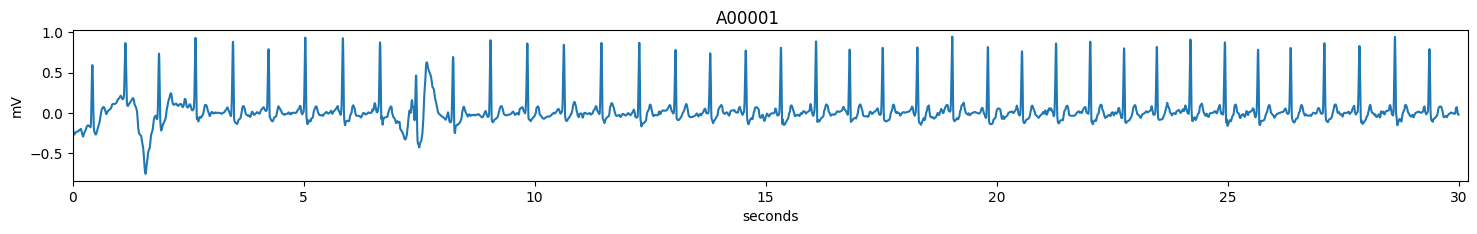

In [3]:

fig, ax = plt.subplots()

fig.suptitle(file_name)
fig.set_size_inches(18, 2)
fig.set_dpi(100)

ax.set_xlabel('seconds')
ax.set_ylabel('mV')
ax.set_xlim(left=0, right=duration+0.2)

ax.plot(x, y)
fig.show()